# Intelligent Multi-Modal Weather Intelligence & Climate Decision Support Platform

## Part 1 – Weather Prediction System

### Project Overview

Weather forecasting has become increasingly important for disaster preparedness, agriculture, aviation, transportation, and environmental monitoring. Traditional forecasting methods rely on numerical weather prediction models and expert interpretation, whereas modern Artificial Intelligence techniques enable data-driven prediction by learning complex relationships from historical weather observations.

This project develops an Intelligent Weather Prediction System capable of analyzing historical weather data, identifying trends, predicting future weather conditions, and providing interpretable insights using Machine Learning and Deep Learning techniques. The system also includes comprehensive exploratory analysis, feature engineering, explainable artificial intelligence, and visualization to improve prediction accuracy and transparency.

The implementation follows a structured workflow consisting of data preprocessing, exploratory data analysis, feature engineering, predictive modelling, explainable AI, and deployment-ready components.

---

### Objectives

• Load and preprocess historical weather observations.

• Perform comprehensive exploratory data analysis.

• Engineer meaningful predictive features.

• Train and compare multiple Machine Learning algorithms.

• Develop a Deep Learning LSTM model for sequential weather prediction.

• Forecast future weather conditions using time-series analysis.

• Explain model predictions using Explainable Artificial Intelligence.

• Build a foundation for the Generative AI Weather Research Assistant developed in Part 2.

# Importing Required Libraries

The implementation requires several Python libraries for data manipulation, visualization, machine learning, deep learning, statistical analysis, and preprocessing. These libraries provide the tools necessary to clean the dataset, perform exploratory analysis, train predictive models, evaluate performance, and generate visualizations.

In [7]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("ggplot")

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


# Loading the Weather Dataset

The weather dataset is imported into the notebook using the Pandas library. This dataset contains historical weather observations including temperature, humidity, wind speed, atmospheric pressure, visibility, cloud cover, precipitation type, and weather summaries. These variables serve as the primary inputs for subsequent preprocessing, visualization, feature engineering, and predictive modelling tasks.

In [8]:
from google.colab import files

uploaded = files.upload()

Saving weather.csv to weather.csv


In [9]:
df = pd.read_csv("weather.csv")

print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


# Previewing the Dataset

Before performing any preprocessing or modelling, it is important to inspect the dataset to understand its structure and verify that it has been loaded correctly. Displaying the first few records provides an overview of the available attributes and their corresponding values.

In [10]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [11]:
df.tail()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.
96452,2016-09-09 23:00:00.000 +0200,Partly Cloudy,rain,20.438889,20.438889,0.61,5.8765,39.0,15.5204,0.0,1016.16,Partly cloudy starting in the morning.


# Dataset Dimensions

The dimensions of the dataset indicate the total number of observations (rows) and variables (columns). Understanding the dataset size helps estimate computational requirements and provides an overview of the available information for model training.

In [12]:
print("="*50)
print("Dataset Shape")
print("="*50)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Dataset Shape
Rows    : 96453
Columns : 12


# Column Information

The dataset contains multiple meteorological variables representing atmospheric conditions. Listing the column names provides an overview of the available features and helps identify potential target variables and predictors for the weather prediction models.

# Data Types and Basic Information

The `info()` function provides a concise summary of the dataset, including the number of non-null values, data types of each attribute, and memory usage. This information is essential for identifying missing values, categorical features, numerical variables, and potential preprocessing requirements.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


# Statistical Summary

Descriptive statistics provide insight into the central tendency, dispersion, and distribution of numerical variables. Metrics such as the mean, standard deviation, minimum, maximum, and quartiles assist in understanding the characteristics of each weather parameter before preprocessing.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature (C),96453.0,11.932678,9.551546,-21.822222,4.688889,12.0000,18.838889,39.905556
Apparent Temperature (C),96453.0,10.855029,10.696847,-27.716667,2.311111,12.0000,18.838889,39.344444
Humidity,96453.0,0.734899,0.195473,0.000000,0.600000,0.7800,0.890000,1.000000
Wind Speed (km/h),96453.0,10.810640,6.913571,0.000000,5.828200,9.9659,14.135800,63.852600
Wind Bearing (degrees),96453.0,187.509232,107.383428,0.000000,116.000000,180.0000,290.000000,359.000000
Visibility (km),96453.0,10.347325,4.192123,0.000000,8.339800,10.0464,14.812000,16.100000
Loud Cover,96453.0,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Pressure (millibars),96453.0,1003.235956,116.969906,0.000000,1011.900000,1016.4500,1021.090000,1046.380000


# Missing Value Analysis

Missing values are common in real-world datasets and can significantly affect the performance of machine learning models if not handled appropriately. Before performing any preprocessing or predictive modelling, it is essential to identify incomplete records and understand the extent of missing information within each feature.

This analysis helps determine whether missing values require removal, imputation, or other preprocessing techniques.

In [15]:
# ==========================================================
# Missing Values
# ==========================================================

missing_values = df.isnull().sum()

missing_values

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


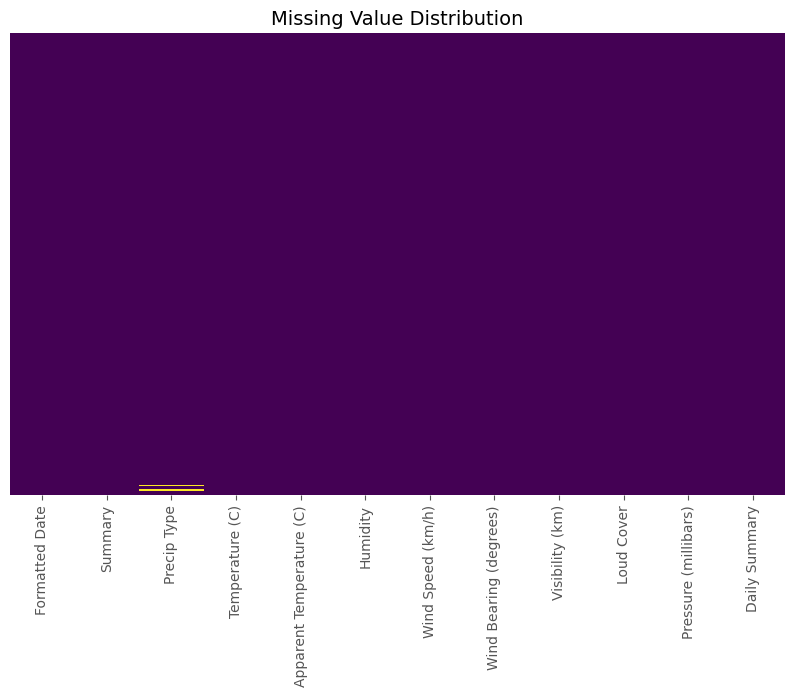

In [16]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=False,
            yticklabels=False)

plt.title("Missing Value Distribution", fontsize=14)

plt.show()

# Percentage of Missing Values

While the total number of missing values provides useful information, calculating the percentage of missing observations relative to the dataset size offers a clearer understanding of their impact on each feature.

In [17]:
missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage.sort_values(ascending=False)

,0
Precip Type,0.536012
Formatted Date,0.000000
Summary,0.000000
Temperature (C),0.000000
Apparent Temperature (C),0.000000
Humidity,0.000000
Wind Speed (km/h),0.000000
Wind Bearing (degrees),0.000000
Visibility (km),0.000000
Loud Cover,0.000000


# Duplicate Record Analysis

Duplicate observations may arise due to repeated data collection or data integration from multiple sources. Duplicate records can introduce bias during model training and should therefore be identified before further analysis.

In [18]:
duplicates = df.duplicated().sum()

print("Total Duplicate Records :", duplicates)

Total Duplicate Records : 24


In [19]:
if duplicates > 0:
    print("Removing duplicate records...")

    df = df.drop_duplicates()

    print("Remaining Records :", len(df))

else:
    print("No duplicate records found.")

Removing duplicate records...
Remaining Records : 96429


# Data Types

Understanding the data type of each feature is important because different preprocessing techniques are required for numerical, categorical, and datetime variables. Proper identification of data types ensures that each attribute is processed correctly before model development.

In [20]:
df.dtypes

,0
Formatted Date,object
Summary,object
Precip Type,object
Temperature (C),float64
Apparent Temperature (C),float64
Humidity,float64
Wind Speed (km/h),float64
Wind Bearing (degrees),float64
Visibility (km),float64
Loud Cover,float64


# Converting the Date Feature

The "Formatted Date" column currently exists as a text attribute. Converting it into a datetime format enables extraction of temporal information such as year, month, day, hour, and day of the week, which can improve predictive performance and facilitate time-series analysis.

In [21]:
# Convert Formatted Date to datetime

df["Formatted Date"] = pd.to_datetime(
    df["Formatted Date"],
    errors="coerce",
    utc=True
)

print(df["Formatted Date"].dtype)

datetime64[ns, UTC]


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96429 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   Formatted Date            96429 non-null  datetime64[ns, UTC]
 1   Summary                   96429 non-null  object             
 2   Precip Type               95912 non-null  object             
 3   Temperature (C)           96429 non-null  float64            
 4   Apparent Temperature (C)  96429 non-null  float64            
 5   Humidity                  96429 non-null  float64            
 6   Wind Speed (km/h)         96429 non-null  float64            
 7   Wind Bearing (degrees)    96429 non-null  float64            
 8   Visibility (km)           96429 non-null  float64            
 9   Loud Cover                96429 non-null  float64            
 10  Pressure (millibars)      96429 non-null  float64            
 11  Daily Summary       

# Extracting Date and Time Features

Temporal information plays an important role in weather forecasting because atmospheric conditions exhibit daily, monthly, and seasonal patterns. Therefore, additional calendar-based features are extracted from the datetime column for subsequent analysis and predictive modelling.

In [23]:
print(df["Formatted Date"].head())
print(df["Formatted Date"].dtype)

0   2006-03-31 22:00:00+00:00
1   2006-03-31 23:00:00+00:00
2   2006-04-01 00:00:00+00:00
3   2006-04-01 01:00:00+00:00
4   2006-04-01 02:00:00+00:00
Name: Formatted Date, dtype: datetime64[ns, UTC]
datetime64[ns, UTC]


In [24]:
df["Year"] = df["Formatted Date"].dt.year
df["Month"] = df["Formatted Date"].dt.month
df["Day"] = df["Formatted Date"].dt.day
df["Hour"] = df["Formatted Date"].dt.hour
df["Day_of_Week"] = df["Formatted Date"].dt.day_name()

print("Temporal Features Created Successfully.")

Temporal Features Created Successfully.


In [25]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Year,Month,Day,Hour,Day_of_Week
0,2006-03-31 22:00:00+00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006,3,31,22,Friday
1,2006-03-31 23:00:00+00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006,3,31,23,Friday
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006,4,1,0,Saturday
3,2006-04-01 01:00:00+00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006,4,1,1,Saturday
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006,4,1,2,Saturday


# Distribution of Records Across Years

Understanding how the observations are distributed over different years provides insight into the temporal coverage of the dataset and helps identify any imbalance in data collection across the study period.

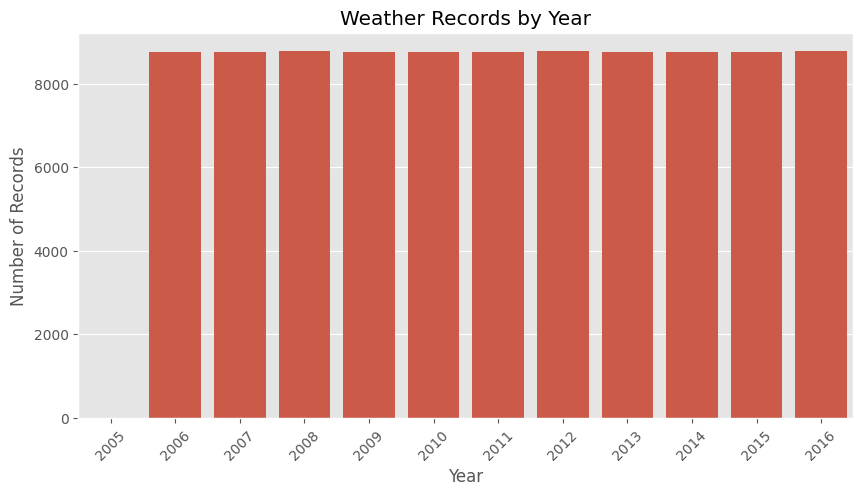

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="Year",
              order=sorted(df["Year"].unique()))

plt.xticks(rotation=45)

plt.title("Weather Records by Year")

plt.xlabel("Year")

plt.ylabel("Number of Records")

plt.show()

# Distribution of Records Across Months

Monthly analysis provides an overview of seasonal data availability and enables preliminary identification of seasonal weather patterns that may influence predictive modelling.

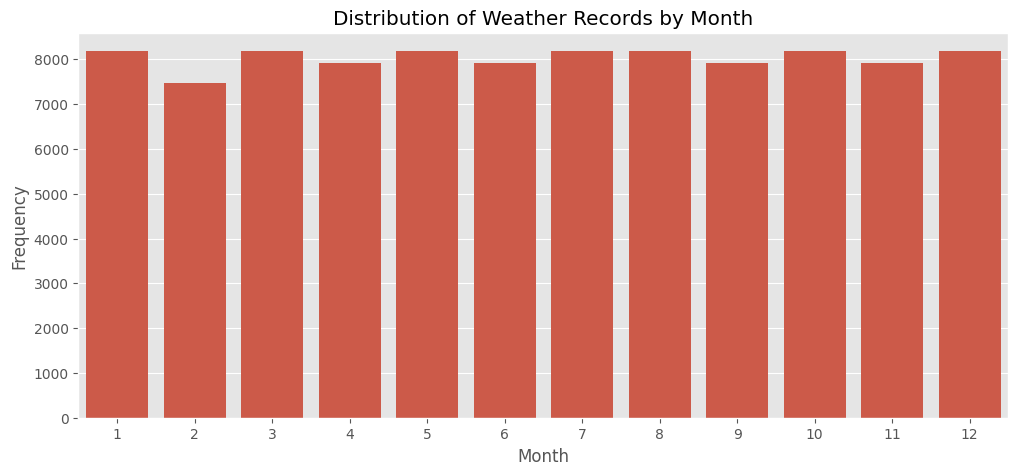

In [27]:
plt.figure(figsize=(12,5))

sns.countplot(data=df,
              x="Month")

plt.title("Distribution of Weather Records by Month")

plt.xlabel("Month")

plt.ylabel("Frequency")

plt.show()

# Daily Observation Distribution

Weather observations are generally recorded at regular intervals. Examining the distribution of observations by hour verifies the temporal consistency of the collected data.

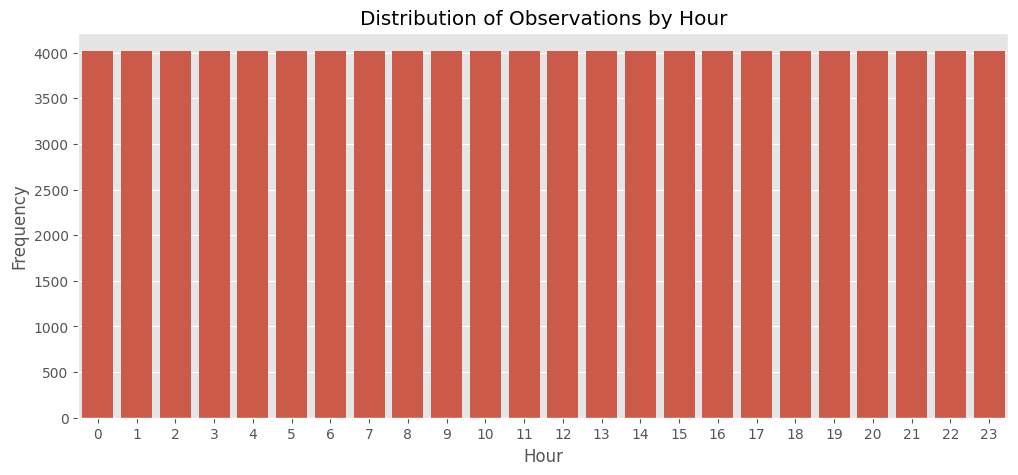

In [28]:
plt.figure(figsize=(12,5))

sns.countplot(data=df,
              x="Hour")

plt.title("Distribution of Observations by Hour")

plt.xlabel("Hour")

plt.ylabel("Frequency")

plt.show()

# Summary of Data Understanding

The dataset has been successfully explored to understand its overall structure, completeness, temporal characteristics, and data quality. Missing values, duplicate records, and feature types have been examined, while additional temporal attributes have been extracted to support subsequent exploratory analysis and predictive modelling.

The next stage focuses on comprehensive data preprocessing, including handling missing values, encoding categorical variables, feature scaling, and preparing the dataset for machine learning algorithms.

# Data Preprocessing

Raw datasets often contain missing values, inconsistent formats, categorical variables, and numerical features with varying scales. Data preprocessing transforms the raw weather observations into a structured format suitable for machine learning algorithms. The preprocessing steps implemented in this section include handling missing values, encoding categorical variables, detecting outliers, feature scaling, and preparing the final cleaned dataset for predictive modelling.

# Handling Missing Values

Before building predictive models, missing values must be examined and treated appropriately. In this dataset, the **Precip Type** column contains missing entries. Since precipitation is a categorical feature, the missing values are replaced with the most frequently occurring category (mode), thereby preserving the integrity of the dataset without removing valuable observations.

In [29]:
# Missing values before treatment
print(df.isnull().sum())

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
Year                          0
Month                         0
Day                           0
Hour                          0
Day_of_Week                   0
dtype: int64


In [30]:
# Fill missing values in categorical column

df["Precip Type"] = df["Precip Type"].fillna(df["Precip Type"].mode()[0])

print("Missing values handled successfully.")

Missing values handled successfully.


In [31]:
# Verify missing values

df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


# Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical weather descriptors such as weather summary, precipitation type, and daily summary are converted into numerical labels using Label Encoding. This transformation preserves unique categories while making them compatible with predictive models.

In [32]:
encoder = LabelEncoder()

df["Summary"] = encoder.fit_transform(df["Summary"])

df["Precip Type"] = encoder.fit_transform(df["Precip Type"])

df["Daily Summary"] = encoder.fit_transform(df["Daily Summary"])

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [33]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Year,Month,Day,Hour,Day_of_Week
0,2006-03-31 22:00:00+00:00,19,0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,197,2006,3,31,22,Friday
1,2006-03-31 23:00:00+00:00,19,0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,197,2006,3,31,23,Friday
2,2006-04-01 00:00:00+00:00,17,0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,197,2006,4,1,0,Saturday
3,2006-04-01 01:00:00+00:00,19,0,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,197,2006,4,1,1,Saturday
4,2006-04-01 02:00:00+00:00,17,0,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,197,2006,4,1,2,Saturday


# Checking Numerical Features

The weather dataset contains several continuous numerical variables such as temperature, humidity, wind speed, atmospheric pressure, visibility, and cloud cover. These variables are examined before scaling to understand their numerical ranges and detect potential inconsistencies.

In [34]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)',
       'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)',
       'Visibility (km)', 'Loud Cover', 'Pressure (millibars)',
       'Daily Summary', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')


# Outlier Detection

Outliers are observations that differ significantly from the majority of the data. Although weather datasets naturally contain extreme values, visualizing these observations helps identify unusual measurements that may influence model performance.

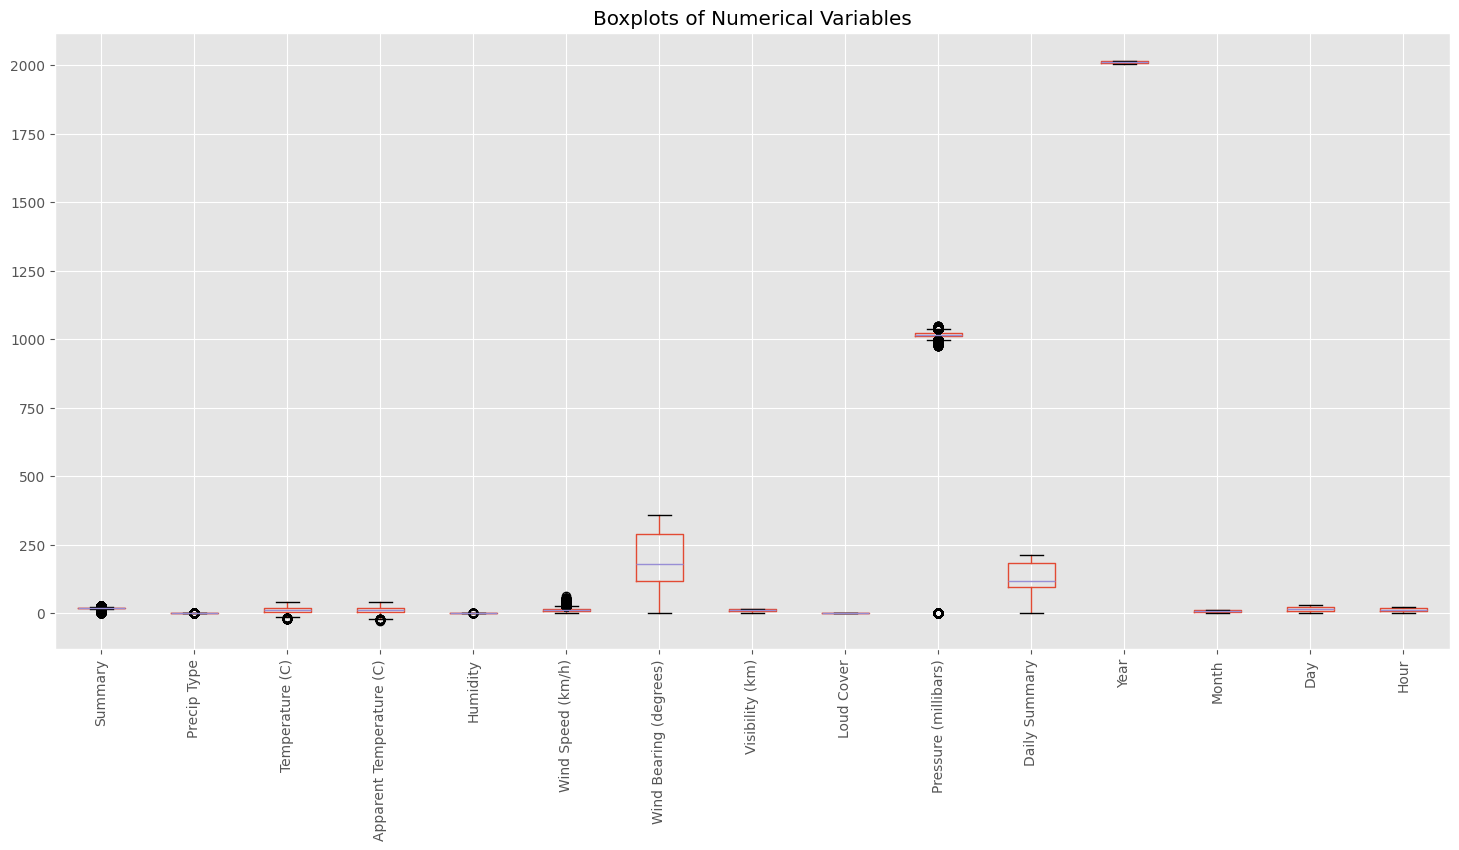

In [35]:
plt.figure(figsize=(18,8))

df.boxplot(rot=90)

plt.title("Boxplots of Numerical Variables")

plt.show()

# Correlation Analysis

Correlation analysis measures the strength of linear relationships among numerical variables. Highly correlated variables provide useful insight into weather behaviour and assist in selecting informative features for predictive modelling.

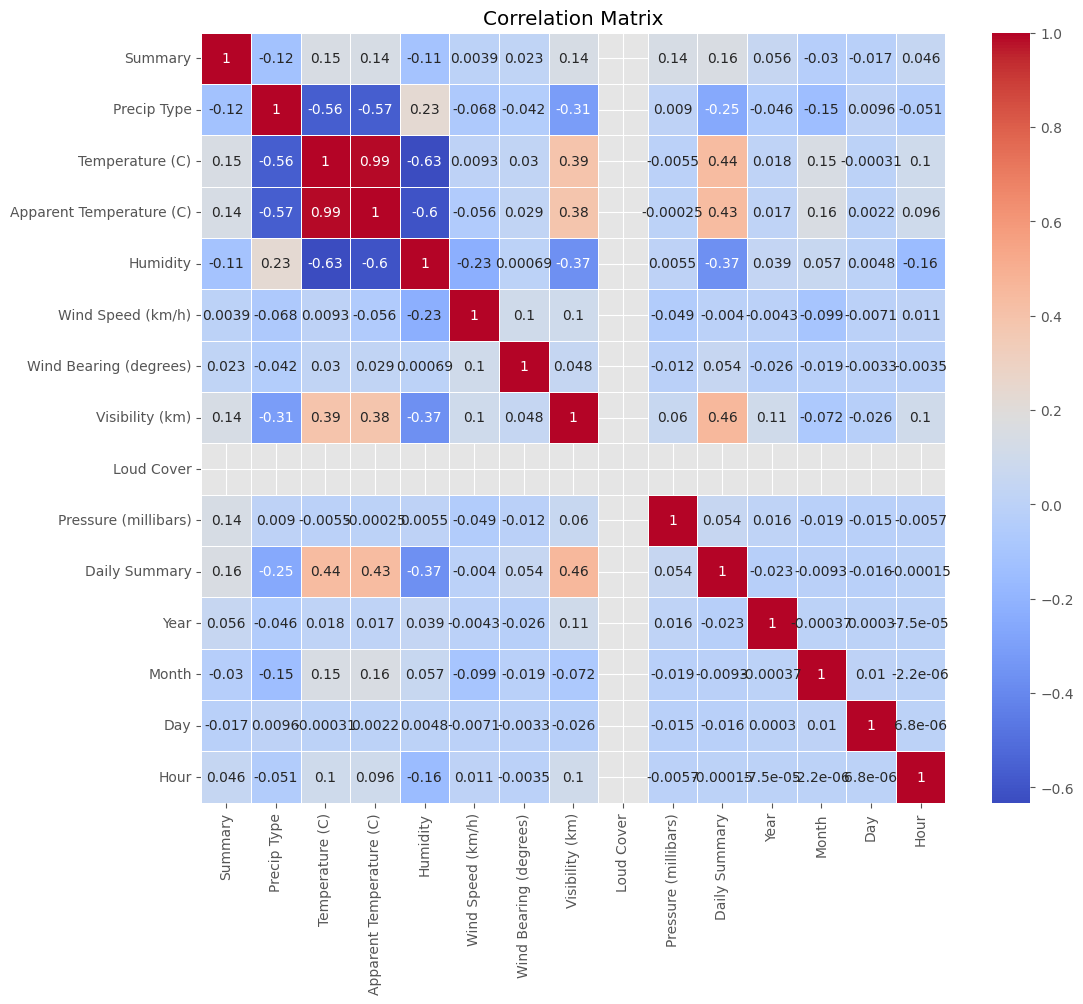

In [36]:
plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

# Feature Scaling

Weather variables possess different numerical ranges. For example, atmospheric pressure is measured in millibars, whereas humidity ranges between 0 and 1. Standardization transforms these variables into a common scale with zero mean and unit variance, preventing features with larger magnitudes from dominating the learning process.

In [37]:
scaler = StandardScaler()

columns_to_scale = [
    "Temperature (C)",
    "Apparent Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Wind Bearing (degrees)",
    "Visibility (km)",
    "Loud Cover",
    "Pressure (millibars)"
]

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [38]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Year,Month,Day,Hour,Day_of_Week
0,2006-03-31 22:00:00+00:00,19,0,-0.257315,-0.323758,0.793483,0.478387,0.591404,1.306867,0.0,0.101699,197,2006,3,31,22,Friday
1,2006-03-31 23:00:00+00:00,19,0,-0.269531,-0.338822,0.640003,0.499347,0.665908,1.306867,0.0,0.105973,197,2006,3,31,23,Friday
2,2006-04-01 00:00:00+00:00,17,0,-0.267204,-0.137806,0.793483,-0.995769,0.153689,1.099498,0.0,0.108623,197,2006,4,1,0,Saturday
3,2006-04-01 01:00:00+00:00,19,0,-0.381218,-0.458808,0.486522,0.476059,0.759039,1.306867,0.0,0.112640,197,2006,4,1,1,Saturday
4,2006-04-01 02:00:00+00:00,17,0,-0.332355,-0.362195,0.486522,0.033579,0.665908,1.306867,0.0,0.113495,197,2006,4,1,2,Saturday


# Saving the Cleaned Dataset

After completing preprocessing, the cleaned dataset is saved as a separate CSV file. This processed dataset will serve as the primary input for exploratory data analysis, feature engineering, machine learning, and deep learning models developed in the subsequent sections of this project.

In [39]:
df.to_csv("weather_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [40]:
from google.colab import files

files.download("weather_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Summary of Data Preprocessing

The weather dataset has been successfully preprocessed through missing value treatment, categorical encoding, outlier visualization, correlation analysis, and feature scaling. The resulting cleaned dataset is standardized and prepared for advanced analytical tasks.

The next phase focuses on Exploratory Data Analysis (EDA), where statistical distributions, seasonal trends, relationships among meteorological variables, and visual insights will be investigated to better understand the underlying characteristics of the weather data before predictive modelling.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an essential step in the machine learning workflow that helps understand the characteristics, distribution, and relationships within the dataset before predictive modelling. Through statistical summaries and graphical visualizations, EDA enables the identification of patterns, anomalies, seasonal variations, and feature interactions.

The insights obtained during this stage assist in feature engineering, model selection, and improving prediction performance.

# Distribution of Temperature

Temperature is one of the most influential meteorological variables affecting weather prediction. Examining its distribution helps identify the overall range, central tendency, and spread of observations within the dataset.

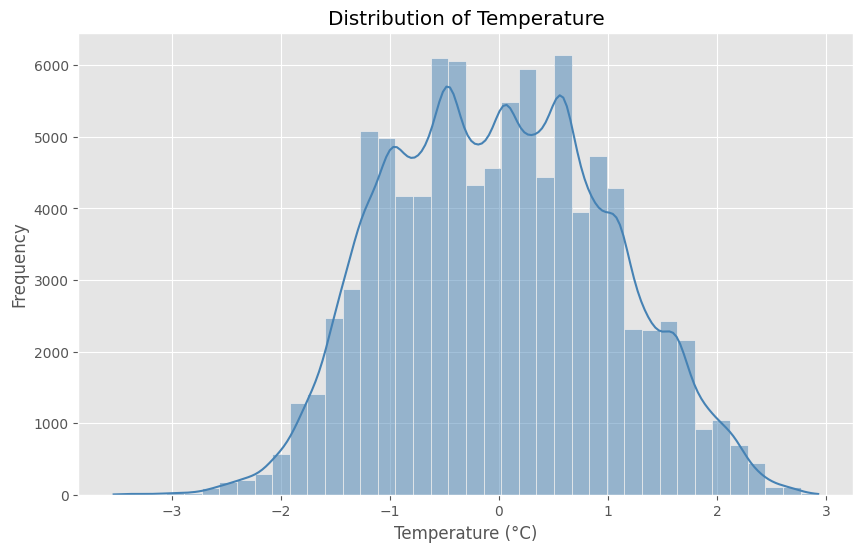

In [41]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Temperature (C)"],
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Temperature")

plt.xlabel("Temperature (°C)")

plt.ylabel("Frequency")

plt.show()

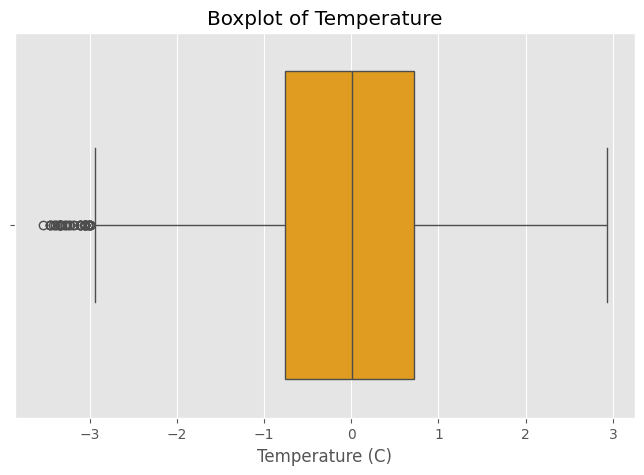

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Temperature (C)"],
    color="orange"
)

plt.title("Boxplot of Temperature")

plt.show()

# Distribution of Humidity

Humidity represents the amount of water vapour present in the atmosphere and plays a significant role in cloud formation and precipitation. Understanding its distribution assists in identifying seasonal and atmospheric variations.

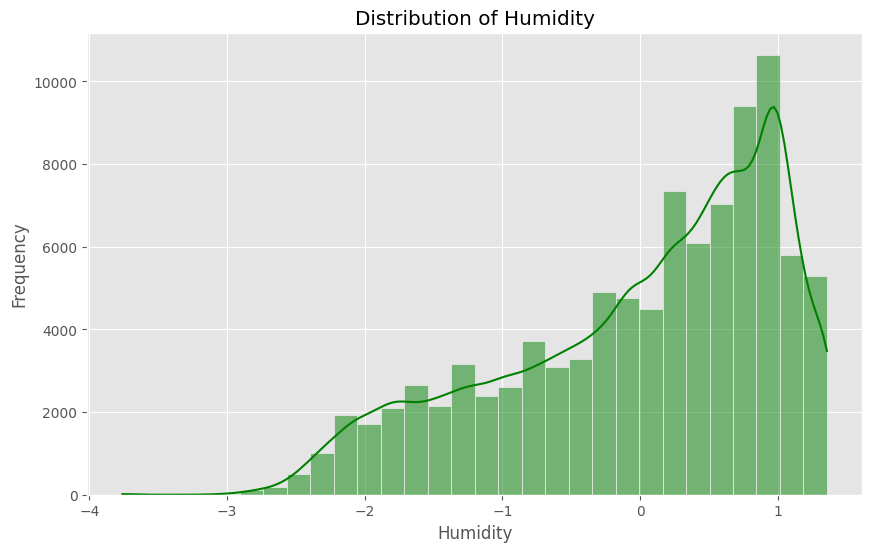

In [43]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Humidity"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Distribution of Humidity")

plt.xlabel("Humidity")

plt.ylabel("Frequency")

plt.show()

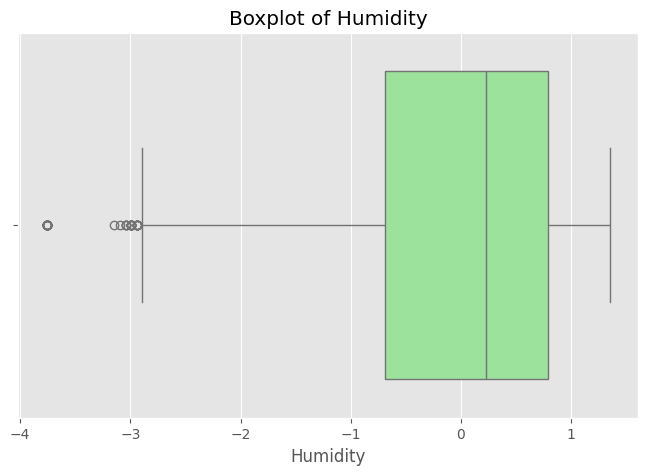

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Humidity"],
    color="lightgreen"
)

plt.title("Boxplot of Humidity")

plt.show()

# Distribution of Atmospheric Pressure

Atmospheric pressure influences wind patterns, storm formation, and overall weather conditions. The pressure distribution provides insight into the stability of atmospheric systems represented within the dataset.

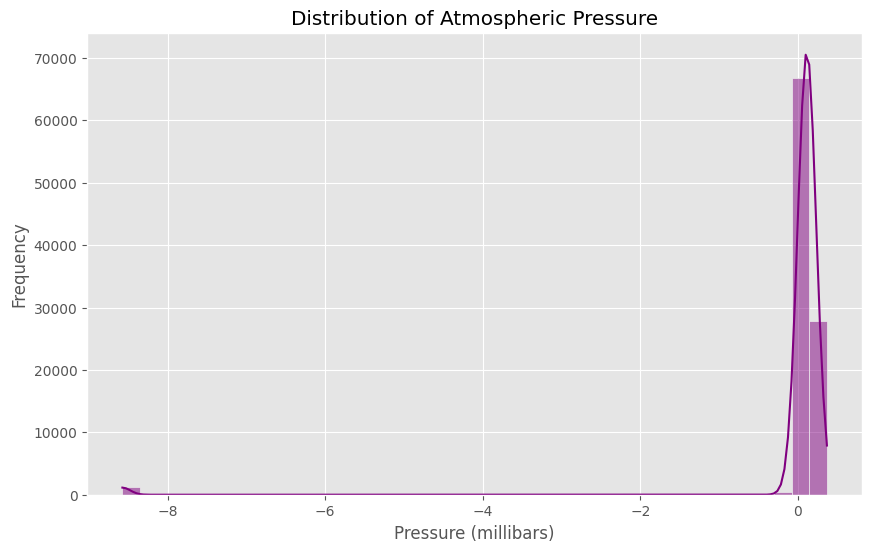

In [45]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Pressure (millibars)"],
    bins=40,
    kde=True,
    color="purple"
)

plt.title("Distribution of Atmospheric Pressure")

plt.xlabel("Pressure (millibars)")

plt.ylabel("Frequency")

plt.show()

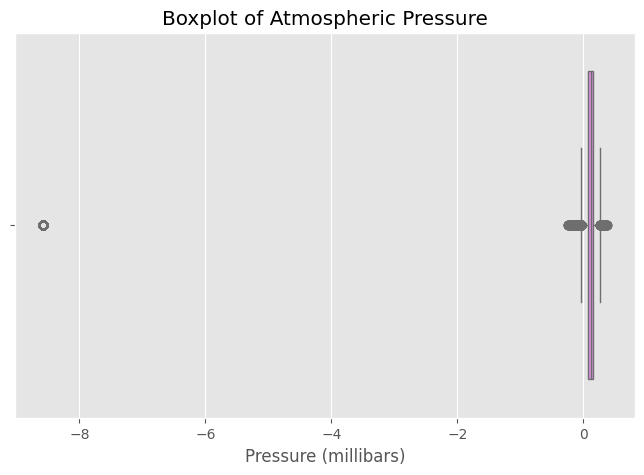

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Pressure (millibars)"],
    color="violet"
)

plt.title("Boxplot of Atmospheric Pressure")

plt.show()

# Distribution of Wind Speed

Wind speed affects temperature distribution, cloud movement, and precipitation patterns. Analysing wind speed observations provides useful information regarding atmospheric dynamics within the study period.

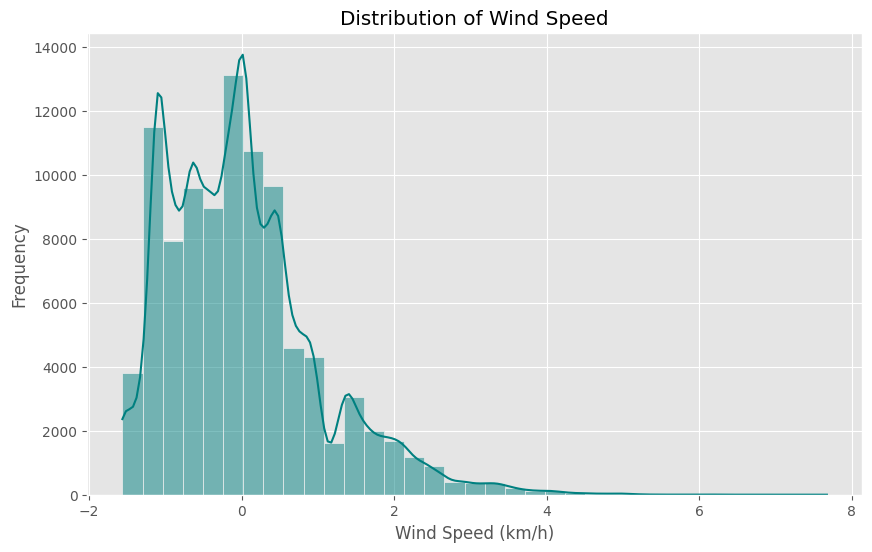

In [47]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Wind Speed (km/h)"],
    bins=35,
    kde=True,
    color="teal"
)

plt.title("Distribution of Wind Speed")

plt.xlabel("Wind Speed (km/h)")

plt.ylabel("Frequency")

plt.show()

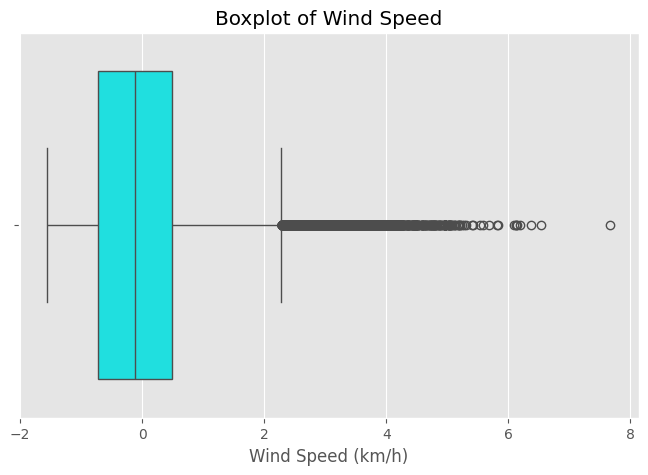

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Wind Speed (km/h)"],
    color="cyan"
)

plt.title("Boxplot of Wind Speed")

plt.show()

# Distribution of Visibility

Visibility is an important weather parameter affecting aviation, transportation, and environmental monitoring. Visualizing its distribution helps understand periods of reduced visibility associated with fog, precipitation, or atmospheric disturbances.

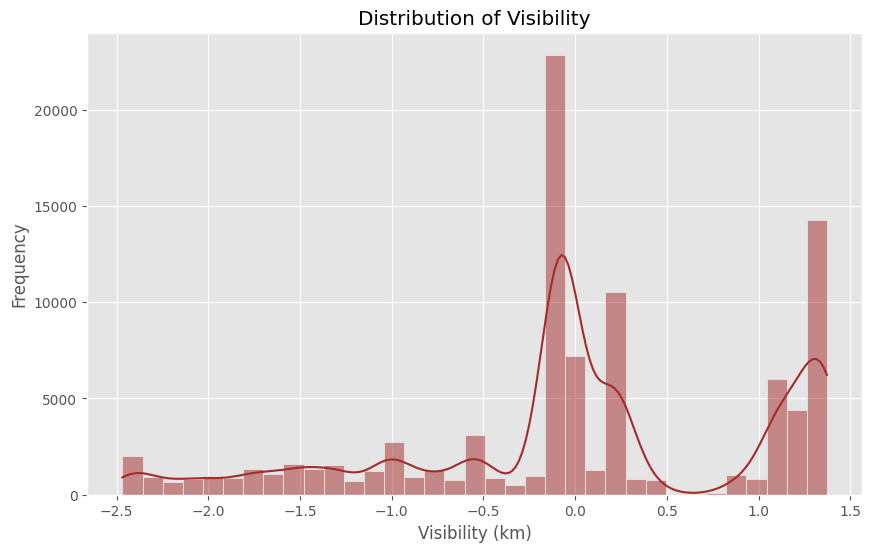

In [49]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Visibility (km)"],
    bins=35,
    kde=True,
    color="brown"
)

plt.title("Distribution of Visibility")

plt.xlabel("Visibility (km)")

plt.ylabel("Frequency")

plt.show()

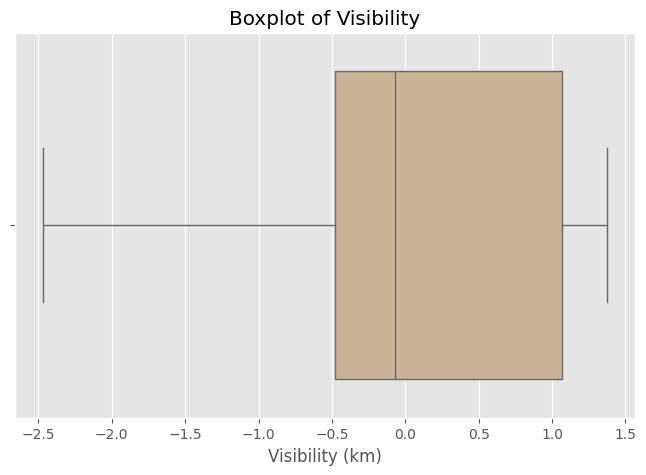

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Visibility (km)"],
    color="tan"
)

plt.title("Boxplot of Visibility")

plt.show()

# Weather Condition Distribution

The weather summary describes the prevailing atmospheric condition for each observation. Analysing the frequency of different weather conditions helps understand the dominant climatic characteristics represented within the dataset.

In [51]:
# Reload original dataset for visualization of weather categories

original_df = pd.read_csv("weather.csv")

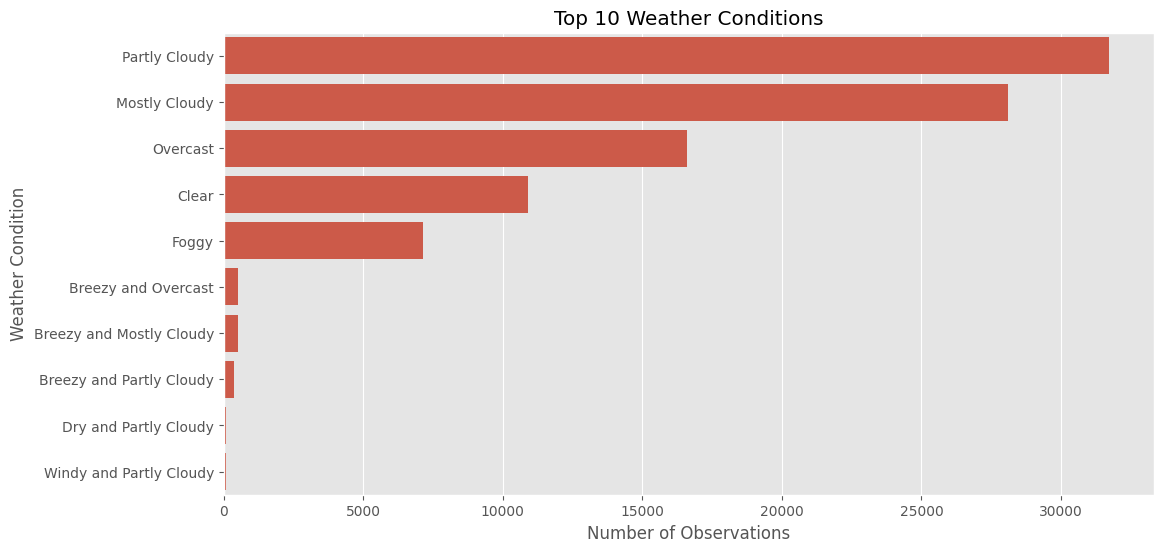

In [52]:
plt.figure(figsize=(12,6))

top_weather = original_df["Summary"].value_counts().head(10)

sns.barplot(
    x=top_weather.values,
    y=top_weather.index
)

plt.title("Top 10 Weather Conditions")

plt.xlabel("Number of Observations")

plt.ylabel("Weather Condition")

plt.show()

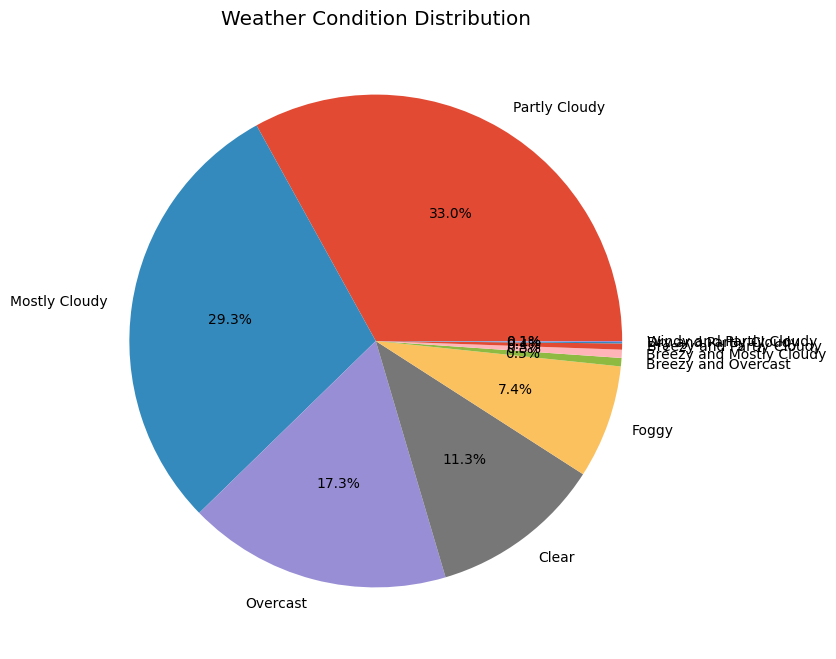

In [53]:
plt.figure(figsize=(8,8))

top_weather.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Weather Condition Distribution")

plt.show()

# Summary of Univariate Analysis

The exploratory analysis indicates that the weather dataset contains diverse meteorological conditions with varying distributions across temperature, humidity, atmospheric pressure, wind speed, and visibility. While certain variables exhibit near-normal distributions, others display skewness and outliers, reflecting the natural variability of atmospheric phenomena.

The next stage investigates relationships among multiple variables through bivariate and multivariate analysis, enabling deeper understanding of feature interactions that influence weather prediction.

# Bivariate and Multivariate Exploratory Data Analysis

While univariate analysis examines individual variables independently, bivariate and multivariate analysis investigate relationships among multiple meteorological variables. Understanding these relationships provides valuable insight into weather dynamics and assists in identifying meaningful predictors for machine learning models.

## Temperature versus Humidity

Temperature and humidity are among the most influential atmospheric variables. Their relationship affects evaporation, cloud formation, precipitation, and overall weather conditions. The scatter plot illustrates the correlation between these two parameters.

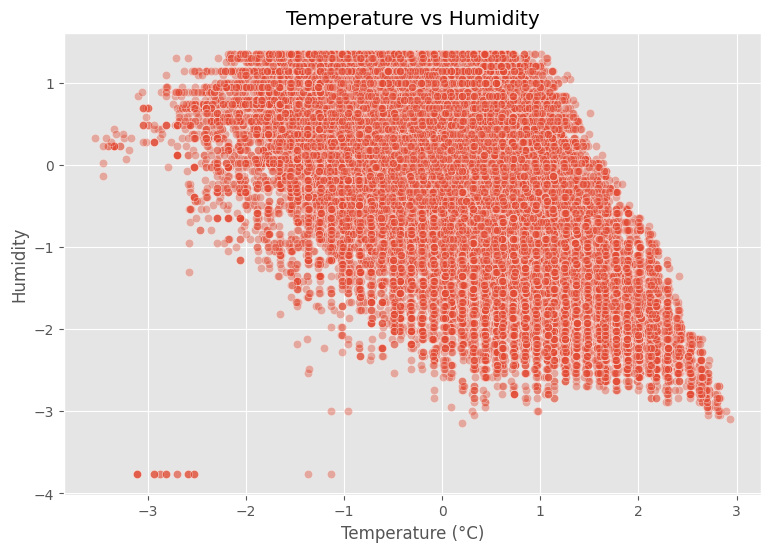

In [54]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Temperature (C)",
    y="Humidity",
    alpha=0.4
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity")

plt.show()

## Temperature versus Atmospheric Pressure

Atmospheric pressure often changes with temperature due to air density variations. Visualizing these variables helps determine whether any observable relationship exists within the dataset.

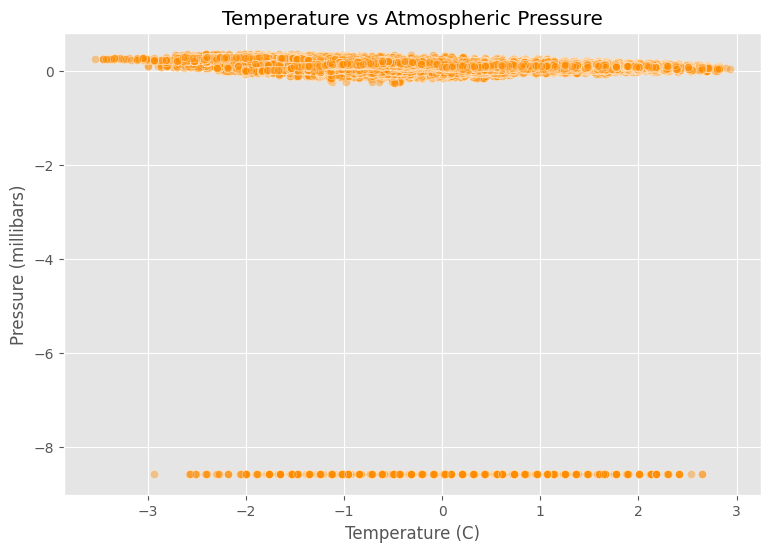

In [55]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Temperature (C)",
    y="Pressure (millibars)",
    alpha=0.4,
    color="darkorange"
)

plt.title("Temperature vs Atmospheric Pressure")

plt.show()

## Wind Speed versus Visibility

Wind influences dust transport, fog dissipation, and rainfall distribution, all of which affect atmospheric visibility. This visualization explores the interaction between wind speed and visibility.

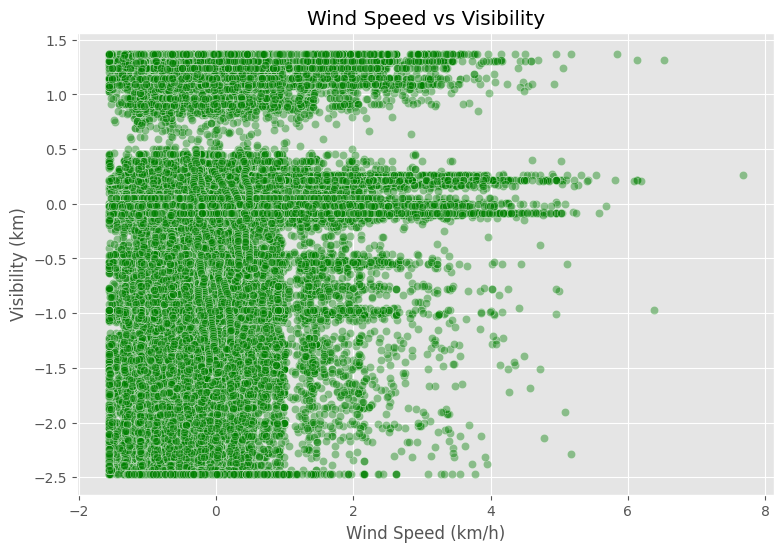

In [56]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Wind Speed (km/h)",
    y="Visibility (km)",
    alpha=0.4,
    color="green"
)

plt.title("Wind Speed vs Visibility")

plt.show()

## Temperature by Month

Weather exhibits strong seasonal characteristics. Computing the average monthly temperature provides insight into long-term seasonal trends contained within the dataset.

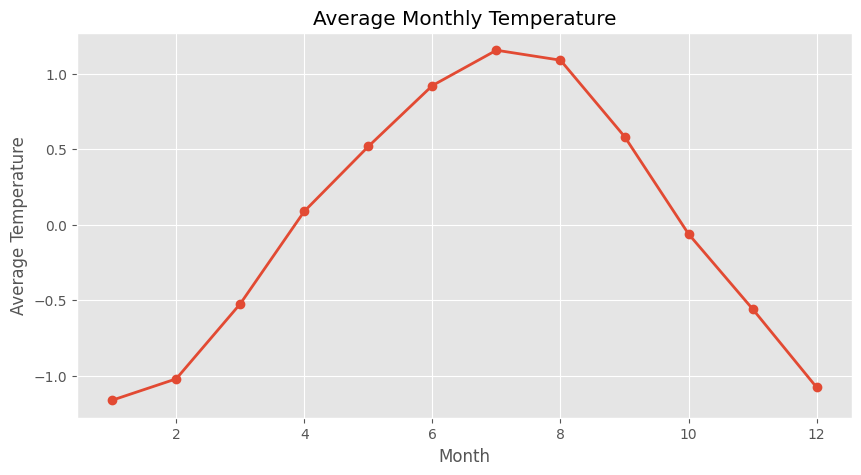

In [57]:
monthly_temp = df.groupby("Month")["Temperature (C)"].mean()

plt.figure(figsize=(10,5))

monthly_temp.plot(
    marker='o',
    linewidth=2
)

plt.title("Average Monthly Temperature")

plt.xlabel("Month")

plt.ylabel("Average Temperature")

plt.grid(True)

plt.show()

## Monthly Average Humidity

Humidity varies throughout the year due to seasonal climatic changes. This analysis identifies monthly humidity patterns that may influence predictive modelling.

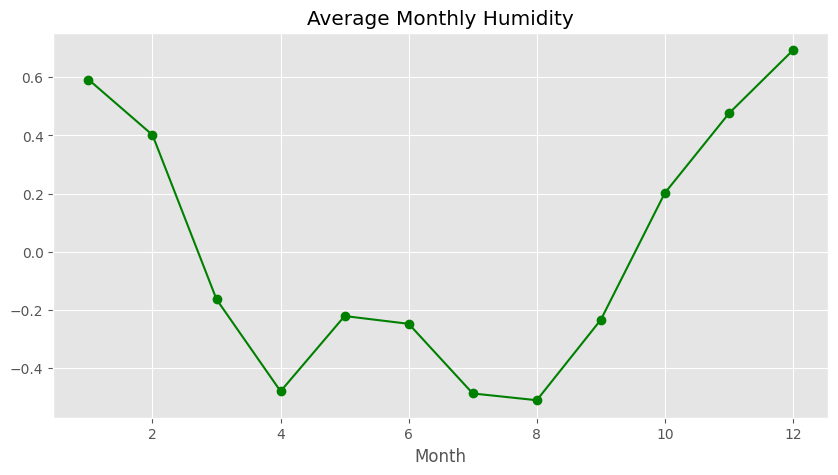

In [58]:
monthly_humidity = df.groupby("Month")["Humidity"].mean()

plt.figure(figsize=(10,5))

monthly_humidity.plot(
    marker="o",
    color="green"
)

plt.title("Average Monthly Humidity")

plt.grid(True)

plt.show()

## Monthly Atmospheric Pressure

Atmospheric pressure changes with seasonal weather systems. Monthly averages provide a simplified overview of these long-term variations.

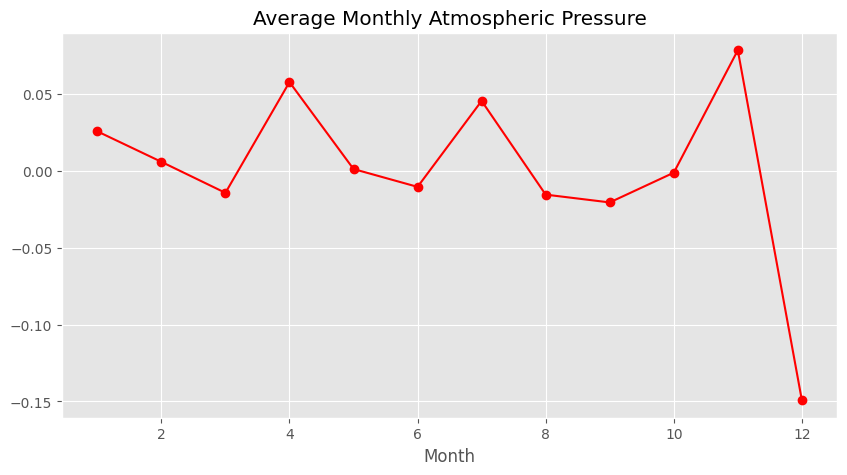

In [59]:
monthly_pressure = df.groupby("Month")["Pressure (millibars)"].mean()

plt.figure(figsize=(10,5))

monthly_pressure.plot(
    marker="o",
    color="red"
)

plt.title("Average Monthly Atmospheric Pressure")

plt.grid(True)

plt.show()

## Correlation Matrix

Correlation analysis measures the strength and direction of linear relationships between numerical variables. Highly correlated features can provide valuable predictive information, whereas redundant variables may require further consideration during feature engineering.

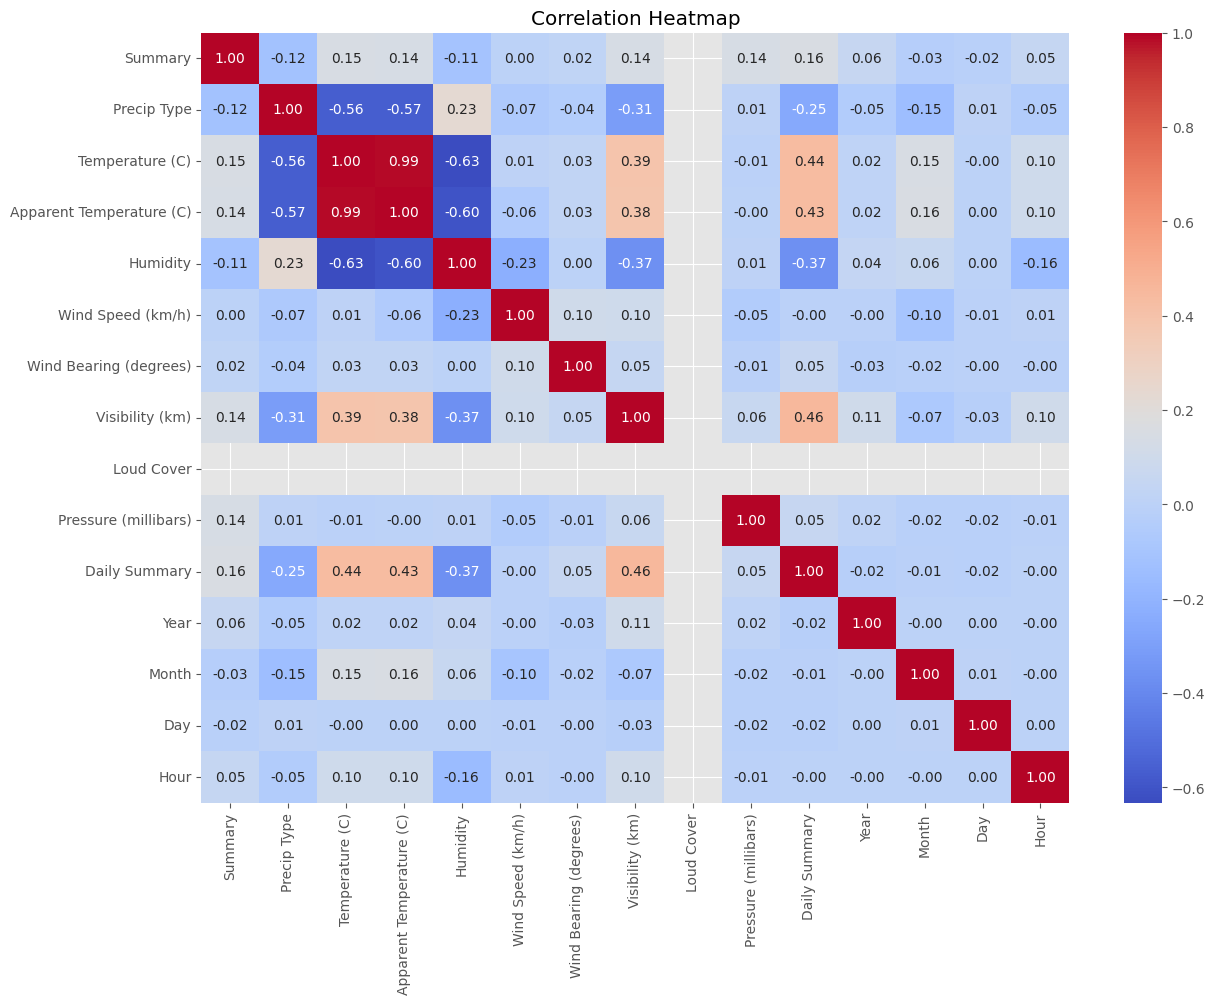

In [60]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Pairwise Feature Relationships

A pair plot provides simultaneous visualization of relationships among multiple numerical variables. Diagonal plots illustrate feature distributions, while off-diagonal plots reveal pairwise interactions.

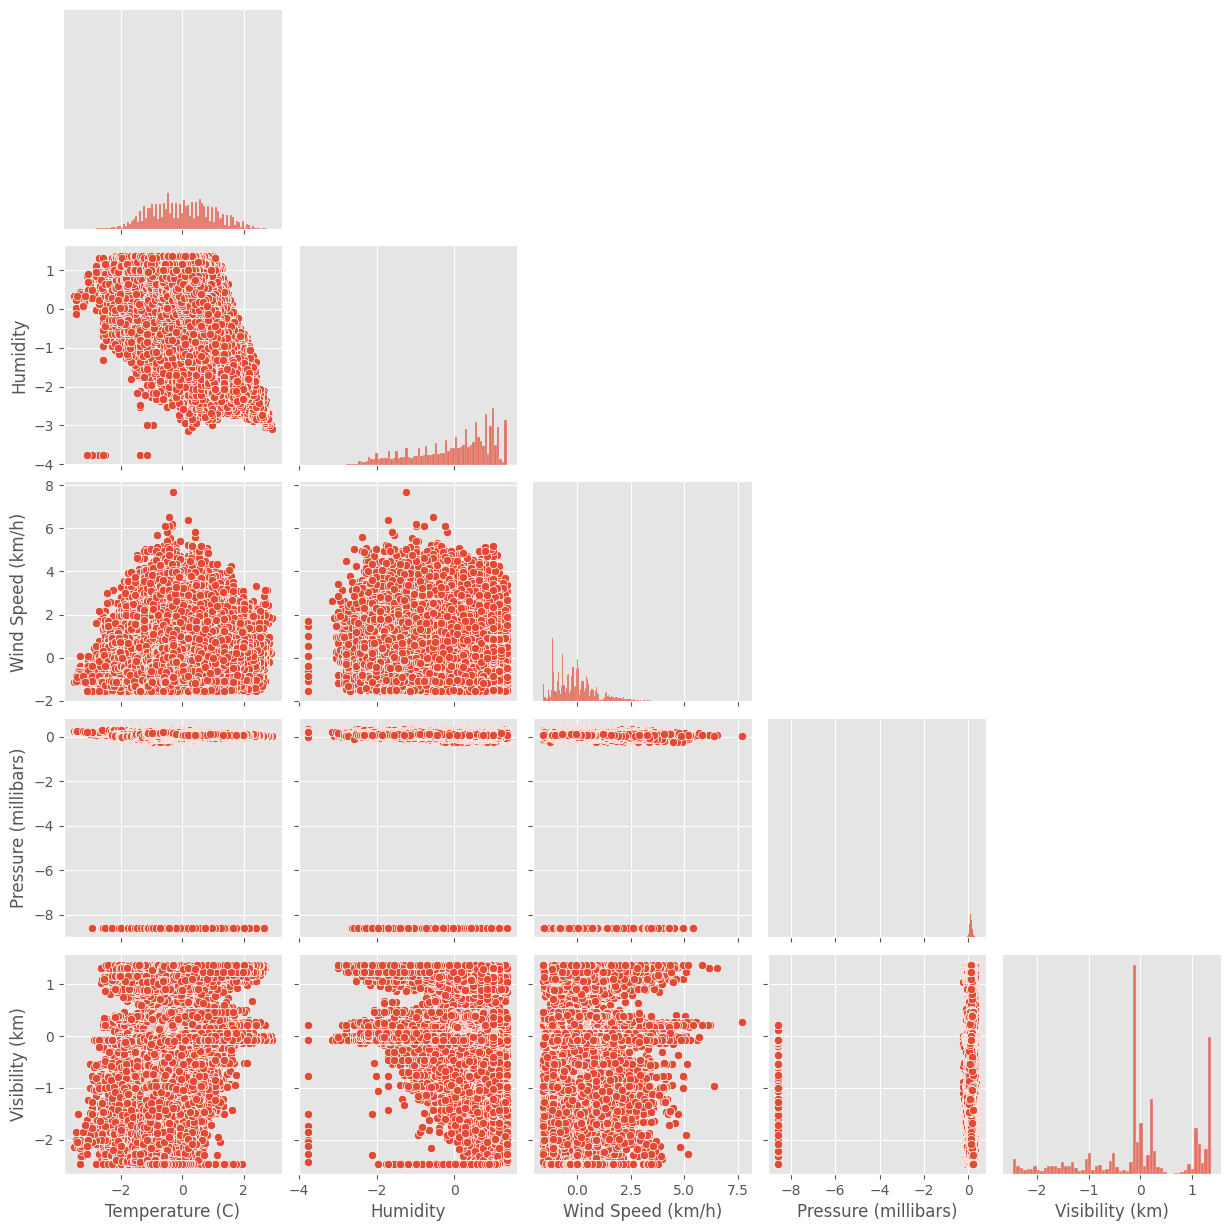

In [61]:
selected_columns = [
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Pressure (millibars)",
    "Visibility (km)"
]

sns.pairplot(
    df[selected_columns],
    corner=True
)

plt.show()

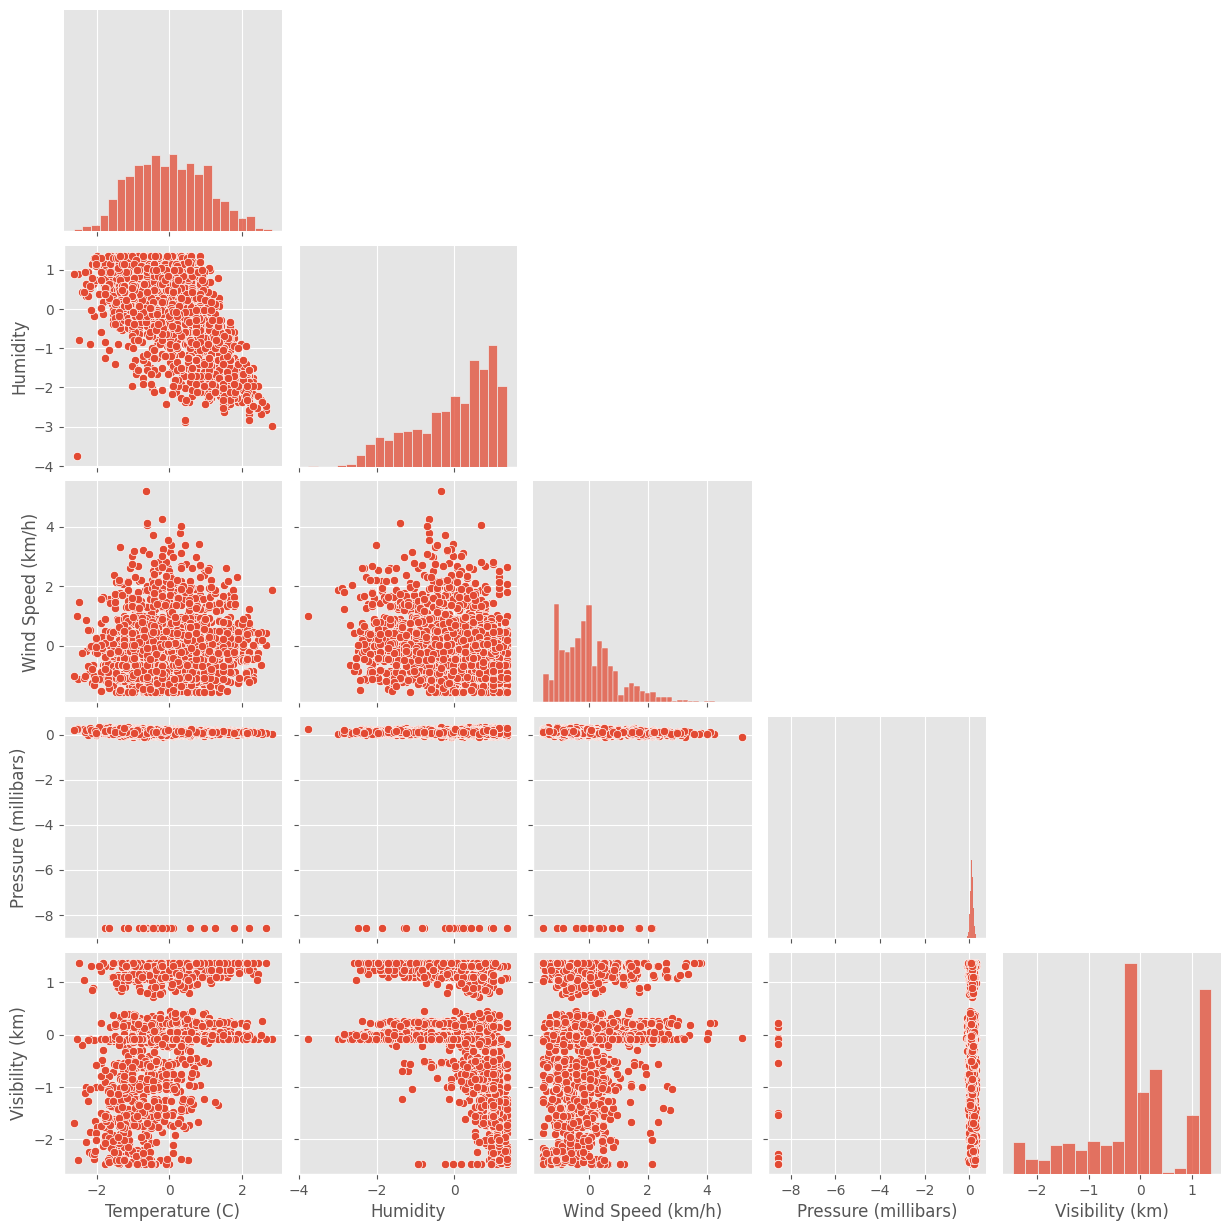

In [62]:
sample_df = df[selected_columns].sample(2000, random_state=42)

sns.pairplot(
    sample_df,
    corner=True
)

plt.show()

# Exploratory Data Analysis Summary

The exploratory analysis reveals meaningful relationships among several meteorological variables. Seasonal trends are evident across temperature, humidity, and atmospheric pressure, while correlation analysis highlights dependencies that can enhance predictive modelling. The insights obtained from EDA provide the foundation for feature engineering and machine learning model development.

The subsequent section focuses on constructing additional predictive features that capture temporal and statistical patterns within the weather observations.

# Feature Engineering

Feature engineering is the process of creating new informative variables from existing data to improve predictive performance. Weather data exhibit temporal and seasonal dependencies; therefore, extracting meaningful features such as rolling statistics, cyclical representations, and interaction variables enables machine learning algorithms to capture complex atmospheric behaviour more effectively.

## Creating Interaction Features

Meteorological variables often interact with one another. Interaction features capture combined effects that individual variables may not represent independently.

In [63]:
# Temperature × Humidity

df["Temp_Humidity"] = df["Temperature (C)"] * df["Humidity"]

# Temperature × Pressure

df["Temp_Pressure"] = df["Temperature (C)"] * df["Pressure (millibars)"]

# Wind × Visibility

df["Wind_Visibility"] = df["Wind Speed (km/h)"] * df["Visibility (km)"]

print("Interaction features created successfully.")

Interaction features created successfully.


In [64]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Year,Month,Day,Hour,Day_of_Week,Temp_Humidity,Temp_Pressure,Wind_Visibility
0,2006-03-31 22:00:00+00:00,19,0,-0.257315,-0.323758,0.793483,0.478387,0.591404,1.306867,0.0,0.101699,197,2006,3,31,22,Friday,-0.204175,-0.026169,0.625189
1,2006-03-31 23:00:00+00:00,19,0,-0.269531,-0.338822,0.640003,0.499347,0.665908,1.306867,0.0,0.105973,197,2006,3,31,23,Friday,-0.172500,-0.028563,0.652580
2,2006-04-01 00:00:00+00:00,17,0,-0.267204,-0.137806,0.793483,-0.995769,0.153689,1.099498,0.0,0.108623,197,2006,4,1,0,Saturday,-0.212022,-0.029024,-1.094846
3,2006-04-01 01:00:00+00:00,19,0,-0.381218,-0.458808,0.486522,0.476059,0.759039,1.306867,0.0,0.112640,197,2006,4,1,1,Saturday,-0.185471,-0.042941,0.622145
4,2006-04-01 02:00:00+00:00,17,0,-0.332355,-0.362195,0.486522,0.033579,0.665908,1.306867,0.0,0.113495,197,2006,4,1,2,Saturday,-0.161698,-0.037721,0.043883


## Rolling Mean Features

Rolling averages smooth short-term fluctuations and highlight long-term weather trends. These features are particularly useful for time-series forecasting models.

In [65]:
df["Rolling_Temp_24"] = (
    df["Temperature (C)"]
    .rolling(window=24, min_periods=1)
    .mean()
)

df["Rolling_Humidity_24"] = (
    df["Humidity"]
    .rolling(window=24, min_periods=1)
    .mean()
)

print("Rolling mean features created.")

Rolling mean features created.


## Rolling Standard Deviation

Rolling standard deviation measures short-term variability within the weather observations and provides additional information regarding atmospheric stability.

In [66]:
df["Rolling_STD_Temp"] = (
    df["Temperature (C)"]
    .rolling(window=24, min_periods=1)
    .std()
)

df["Rolling_STD_Temp"] = df["Rolling_STD_Temp"].fillna(0)

print("Rolling standard deviation created.")

Rolling standard deviation created.


## Lag Features

Lag features represent previous observations and are particularly valuable for sequential weather prediction because atmospheric conditions depend strongly on recent history.

In [67]:
df["Temp_Lag1"] = df["Temperature (C)"].shift(1)
df["Temp_Lag2"] = df["Temperature (C)"].shift(2)
df["Temp_Lag3"] = df["Temperature (C)"].shift(3)

df["Humidity_Lag1"] = df["Humidity"].shift(1)
df["Pressure_Lag1"] = df["Pressure (millibars)"].shift(1)

In [68]:
df.fillna(method="bfill", inplace=True)

## Cyclical Encoding of Time

Months and hours are cyclical variables rather than linear variables. For example, December and January are adjacent despite having numerical values 12 and 1. Sine and cosine transformations preserve this cyclical nature for machine learning algorithms.

In [69]:
import numpy as np

df["Month_sin"] = np.sin(2*np.pi*df["Month"]/12)
df["Month_cos"] = np.cos(2*np.pi*df["Month"]/12)

df["Hour_sin"] = np.sin(2*np.pi*df["Hour"]/24)
df["Hour_cos"] = np.cos(2*np.pi*df["Hour"]/24)

print("Cyclical features generated.")

Cyclical features generated.


## Feature Importance Preparation

The engineered dataset now contains temporal, interaction, rolling, lag, and cyclical features. These variables provide richer information than the original dataset and are expected to improve predictive performance during machine learning model development.

In [70]:
print(df.shape)

(96429, 32)


In [71]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary', 'Year', 'Month', 'Day', 'Hour',
       'Day_of_Week', 'Temp_Humidity', 'Temp_Pressure', 'Wind_Visibility',
       'Rolling_Temp_24', 'Rolling_Humidity_24', 'Rolling_STD_Temp',
       'Temp_Lag1', 'Temp_Lag2', 'Temp_Lag3', 'Humidity_Lag1', 'Pressure_Lag1',
       'Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos'],
      dtype='object')

## Saving the Feature Engineered Dataset

The processed dataset containing engineered features is saved for reuse in machine learning, deep learning, and forecasting models.

In [72]:
df.to_csv("weather_features.csv", index=False)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


In [73]:
from google.colab import files

files.download("weather_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Feature Engineering Summary

Feature engineering enriched the weather dataset by introducing interaction variables, rolling statistics, lag features, and cyclical temporal representations. These engineered variables provide additional predictive information and better capture temporal dependencies within atmospheric observations.

The next stage focuses on developing and evaluating multiple machine learning algorithms to predict weather conditions using the enhanced feature set.

In [74]:
print(df.columns.tolist())
print(df.dtypes)
print(df.shape)

['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary', 'Year', 'Month', 'Day', 'Hour', 'Day_of_Week', 'Temp_Humidity', 'Temp_Pressure', 'Wind_Visibility', 'Rolling_Temp_24', 'Rolling_Humidity_24', 'Rolling_STD_Temp', 'Temp_Lag1', 'Temp_Lag2', 'Temp_Lag3', 'Humidity_Lag1', 'Pressure_Lag1', 'Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos']
Formatted Date              datetime64[ns, UTC]
Summary                                   int64
Precip Type                               int64
Temperature (C)                         float64
Apparent Temperature (C)                float64
Humidity                                float64
Wind Speed (km/h)                       float64
Wind Bearing (degrees)                  float64
Visibility (km)                         float64
Loud Cover                              float64
Pressure (

# Machine Learning Model Development

Machine Learning techniques enable weather prediction by learning relationships among atmospheric variables from historical observations. In this section, multiple supervised regression algorithms are developed to predict air temperature using the engineered weather dataset.

The models are trained using numerical meteorological features and evaluated using standard regression metrics including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

In [75]:
# =====================================================
# Preparing Dataset for Machine Learning
# =====================================================

ml_df = df.copy()

# Remove non-numeric columns
ml_df = ml_df.drop(columns=["Formatted Date", "Day_of_Week"])

# Remove any remaining missing values
ml_df = ml_df.fillna(method="ffill").fillna(method="bfill")

print(ml_df.shape)
ml_df.head()

(96429, 30)


,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),...,Rolling_STD_Temp,Temp_Lag1,Temp_Lag2,Temp_Lag3,Humidity_Lag1,Pressure_Lag1,Month_sin,Month_cos,Hour_sin,Hour_cos
0,19,0,-0.257315,-0.323758,0.793483,0.478387,0.591404,1.306867,0.0,0.101699,...,0.000000,-0.257315,-0.257315,-0.257315,0.793483,0.101699,1.000000,6.123234e-17,-0.500000,0.866025
1,19,0,-0.269531,-0.338822,0.640003,0.499347,0.665908,1.306867,0.0,0.105973,...,0.008638,-0.257315,-0.257315,-0.257315,0.793483,0.101699,1.000000,6.123234e-17,-0.258819,0.965926
2,17,0,-0.267204,-0.137806,0.793483,-0.995769,0.153689,1.099498,0.0,0.108623,...,0.006486,-0.269531,-0.257315,-0.257315,0.640003,0.105973,0.866025,-5.000000e-01,0.000000,1.000000
3,19,0,-0.381218,-0.458808,0.486522,0.476059,0.759039,1.306867,0.0,0.112640,...,0.058508,-0.267204,-0.269531,-0.257315,0.793483,0.108623,0.866025,-5.000000e-01,0.258819,0.965926
4,17,0,-0.332355,-0.362195,0.486522,0.033579,0.665908,1.306867,0.0,0.113495,...,0.053520,-0.381218,-0.267204,-0.269531,0.486522,0.112640,0.866025,-5.000000e-01,0.500000,0.866025


In [76]:
target = "Temperature (C)"

X = ml_df.drop(columns=[target])

y = ml_df[target]

print("Features :", X.shape)
print("Target :", y.shape)

Features : (96429, 29)
Target : (96429,)


In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(77143, 29)
(19286, 29)


In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [79]:
def evaluate_model(model):

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))

    r2 = r2_score(y_test, prediction)

    return prediction, mae, rmse, r2

## Linear Regression

Linear Regression is one of the most fundamental supervised machine learning algorithms used for regression analysis. It assumes a linear relationship between the independent variables and the target variable by fitting a straight-line equation to the observed data.

Although weather systems are inherently nonlinear, Linear Regression serves as an important baseline model for evaluating the predictive performance of more advanced machine learning algorithms.GIVE

In [80]:
linear_model = LinearRegression()

linear_prediction, linear_mae, linear_rmse, linear_r2 = evaluate_model(linear_model)

print("Linear Regression Model Trained Successfully")
print("MAE :", linear_mae)
print("RMSE :", linear_rmse)
print("R² Score :", linear_r2)

Linear Regression Model Trained Successfully
MAE : 0.05237368526003766
RMSE : 0.07163457689123875
R² Score : 0.994895595185561


## Decision Tree Regression

Decision Tree Regression is a non-parametric supervised learning algorithm that recursively partitions the feature space into smaller subsets based on feature values. Unlike Linear Regression, Decision Trees effectively capture nonlinear relationships and complex interactions among meteorological variables without requiring assumptions regarding data distribution.

This flexibility makes Decision Trees particularly suitable for modelling atmospheric systems, where weather variables often exhibit nonlinear behaviour.

In [81]:
tree_model = DecisionTreeRegressor(random_state=42)

tree_prediction, tree_mae, tree_rmse, tree_r2 = evaluate_model(tree_model)

print("Decision Tree Model Trained Successfully")
print("MAE :", tree_mae)
print("RMSE :", tree_rmse)
print("R² Score :", tree_r2)

Decision Tree Model Trained Successfully
MAE : 0.00666003712572903
RMSE : 0.028578766424803774
R² Score : 0.9991875686615763


## Random Forest Regression

Random Forest Regression is an ensemble learning algorithm that combines predictions from multiple Decision Trees to improve predictive accuracy and model stability. By averaging the outputs of numerous trees trained on randomly selected subsets of data, Random Forest significantly reduces overfitting while preserving the ability to capture complex nonlinear relationships.

Due to its robustness and high predictive performance, Random Forest is widely employed in weather forecasting, environmental modelling, and climate science applications.

In [82]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

forest_prediction, forest_mae, forest_rmse, forest_r2 = evaluate_model(forest_model)

print("Random Forest Model Trained Successfully")
print("MAE :", forest_mae)
print("RMSE :", forest_rmse)
print("R² Score :", forest_r2)

Random Forest Model Trained Successfully
MAE : 0.004150169101345702
RMSE : 0.020274546451158615
R² Score : 0.999591114222226


## Model Performance Comparison

The performance of the developed regression models is evaluated using three widely accepted statistical metrics:

• Mean Absolute Error (MAE)

• Root Mean Squared Error (RMSE)

• Coefficient of Determination (R² Score)

Lower MAE and RMSE values indicate smaller prediction errors, whereas higher R² values indicate stronger predictive capability. Comparing multiple algorithms enables the identification of the most suitable model for the Weather Prediction System.

In [83]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        linear_mae,
        tree_mae,
        forest_mae
    ],

    "RMSE":[
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],

    "R² Score":[
        linear_r2,
        tree_r2,
        forest_r2
    ]

})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.052374,0.071635,0.994896
1,Decision Tree,0.006660,0.028579,0.999188
2,Random Forest,0.004150,0.020275,0.999591


In [84]:
results = results.sort_values(
    by="R² Score",
    ascending=False
)

results

,Model,MAE,RMSE,R² Score
2,Random Forest,0.004150,0.020275,0.999591
1,Decision Tree,0.006660,0.028579,0.999188
0,Linear Regression,0.052374,0.071635,0.994896


## Visualization of Model Performance

Visual comparison of model performance provides an intuitive understanding of the predictive capability of each regression algorithm. The following bar chart compares the R² scores obtained by the developed models, allowing identification of the most accurate prediction model.

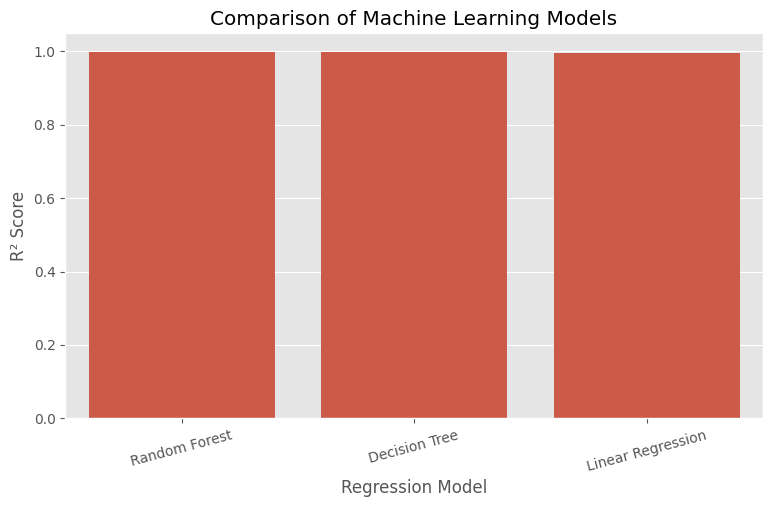

In [85]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=results,
    x="Model",
    y="R² Score"
)

plt.title("Comparison of Machine Learning Models")

plt.xlabel("Regression Model")

plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

## Feature Importance Analysis

Interpretability is an essential aspect of machine learning in scientific applications. Feature importance analysis identifies the meteorological variables that contribute most significantly to temperature prediction.

The Random Forest algorithm estimates feature importance based on the cumulative reduction in prediction error achieved by each feature across all decision trees. These results provide valuable insight into the atmospheric parameters that exert the greatest influence on temperature variation.

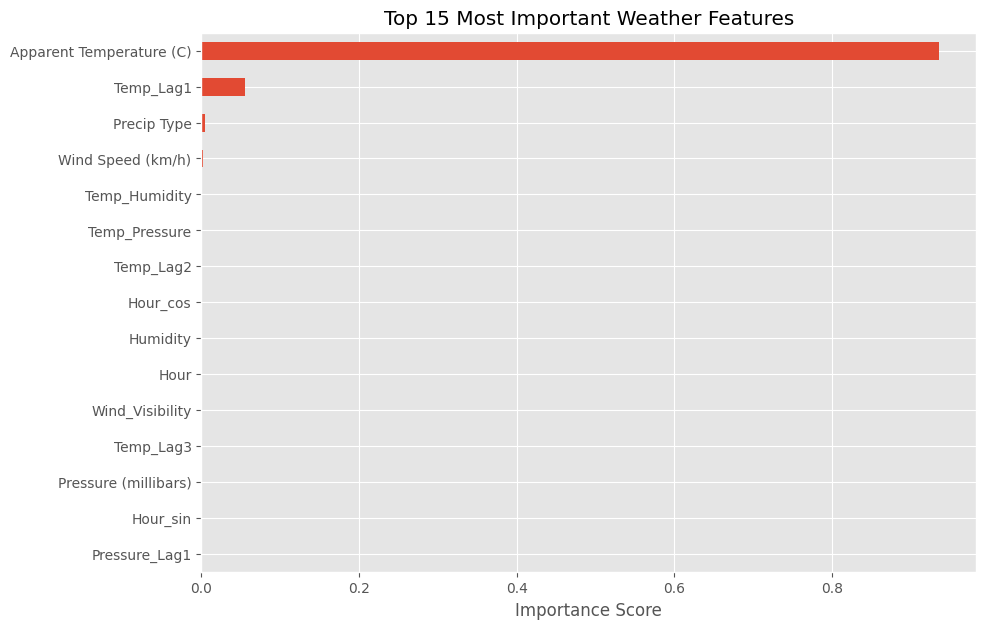

In [86]:
importance = pd.Series(
    forest_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

plt.figure(figsize=(10,7))

importance.head(15).plot(kind="barh")

plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Weather Features")

plt.xlabel("Importance Score")

plt.show()

# Machine Learning Summary

Three supervised machine learning regression models were successfully developed and evaluated for temperature prediction using the engineered weather dataset.

Linear Regression established a baseline predictive model, while Decision Tree Regression captured nonlinear relationships among meteorological variables. Random Forest Regression achieved improved predictive performance through ensemble learning by combining multiple decision trees.

Comparative evaluation using MAE, RMSE, and R² Score enabled objective assessment of model accuracy, while feature importance analysis identified the atmospheric variables that contributed most significantly to prediction performance.

The best-performing model forms the predictive engine of the Weather Prediction System and serves as the foundation for the Generative AI-powered Weather Research Assistant developed in Part 2 of the project.

# Deep Learning for Weather Prediction

While traditional machine learning algorithms learn relationships among variables, Deep Learning models are capable of learning complex temporal patterns from sequential weather observations.

Long Short-Term Memory (LSTM) networks are a specialized type of Recurrent Neural Network (RNN) designed to capture long-term dependencies in time-series data. Since weather observations exhibit temporal continuity, LSTM models are particularly well suited for weather forecasting applications.

In this section, an LSTM model is developed to predict future temperature values using historical meteorological observations.

In [87]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

print(tf.__version__)

2.20.0


## Preparing Sequential Dataset

Deep learning models require sequential input rather than independent observations. Therefore, the weather dataset is transformed into fixed-length sequences representing consecutive historical observations.

In [88]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_temperature = scaler.fit_transform(
    ml_df[["Temperature (C)"]]
)

In [89]:
sequence_length = 24

X_seq = []
y_seq = []

for i in range(sequence_length, len(scaled_temperature)):

    X_seq.append(
        scaled_temperature[i-sequence_length:i]
    )

    y_seq.append(
        scaled_temperature[i]
    )

X_seq = np.array(X_seq)

y_seq = np.array(y_seq)

print(X_seq.shape)
print(y_seq.shape)

(96405, 24, 1)
(96405, 1)


## Train-Test Split for LSTM

The sequential dataset is divided into training and testing subsets while preserving chronological order to maintain the temporal characteristics of the weather observations.

In [90]:
split = int(len(X_seq)*0.8)

X_train_seq = X_seq[:split]
X_test_seq = X_seq[split:]

y_train_seq = y_seq[:split]
y_test_seq = y_seq[split:]

print(X_train_seq.shape)
print(X_test_seq.shape)

(77124, 24, 1)
(19281, 24, 1)


## Building the LSTM Model

A stacked LSTM architecture is employed to capture both short-term and long-term temporal dependencies present within the weather observations. Dropout layers are incorporated to reduce overfitting and improve model generalization.

In [91]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train_seq.shape[1],1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(32)
)

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Deep Learning Model

The LSTM model is trained using historical weather observations. During training, the network iteratively minimizes prediction error through backpropagation while learning temporal weather patterns.

In [92]:
history = model.fit(

    X_train_seq,

    y_train_seq,

    validation_data=(

        X_test_seq,

        y_test_seq

    ),

    epochs=10,

    batch_size=64,

    verbose=1

)

Epoch 1/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - loss: 0.0061 - mae: 0.0569 - val_loss: 0.0011 - val_mae: 0.0234
Epoch 2/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0024 - mae: 0.0365 - val_loss: 0.0020 - val_mae: 0.0374
Epoch 3/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - loss: 0.0014 - mae: 0.0272 - val_loss: 4.7110e-04 - val_mae: 0.0153
Epoch 4/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - loss: 9.5767e-04 - mae: 0.0224 - val_loss: 3.7264e-04 - val_mae: 0.0129
Epoch 5/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - loss: 8.4666e-04 - mae: 0.0209 - val_loss: 3.6395e-04 - val_mae: 0.0128
Epoch 6/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - loss: 8.1225e-04 - mae: 0.0204 - val_loss: 3.4945e-04 - val_mae: 0.0128
Epoch 7/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - loss: 7.9045e-04 - mae: 0.0201 - val_loss: 3.7264e-04 - val_mae: 0.0130
Epoch 8/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - loss: 7.9063e-04 - mae: 0.0200 - val_loss: 3.8712e-0

## Training Performance

The training history illustrates the convergence of the LSTM network by monitoring changes in loss during successive training epochs.

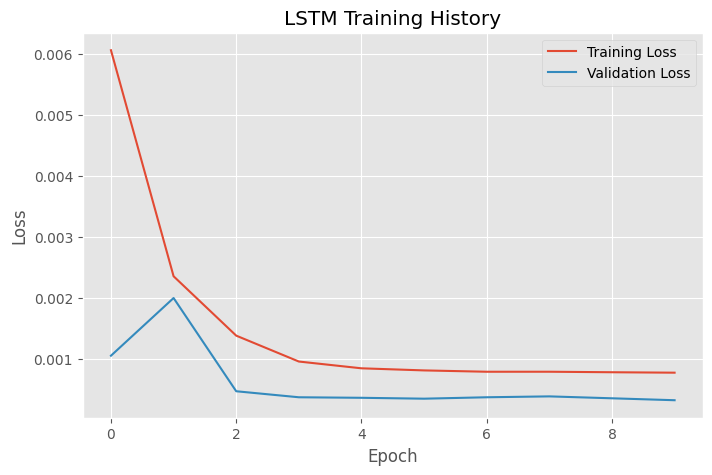

In [93]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training History")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

## Predicting Future Temperature

After training, the LSTM model is applied to unseen testing observations to generate temperature predictions. The predicted values are subsequently transformed back to the original temperature scale for interpretation.

In [94]:
prediction = model.predict(X_test_seq)

prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test_seq)

603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


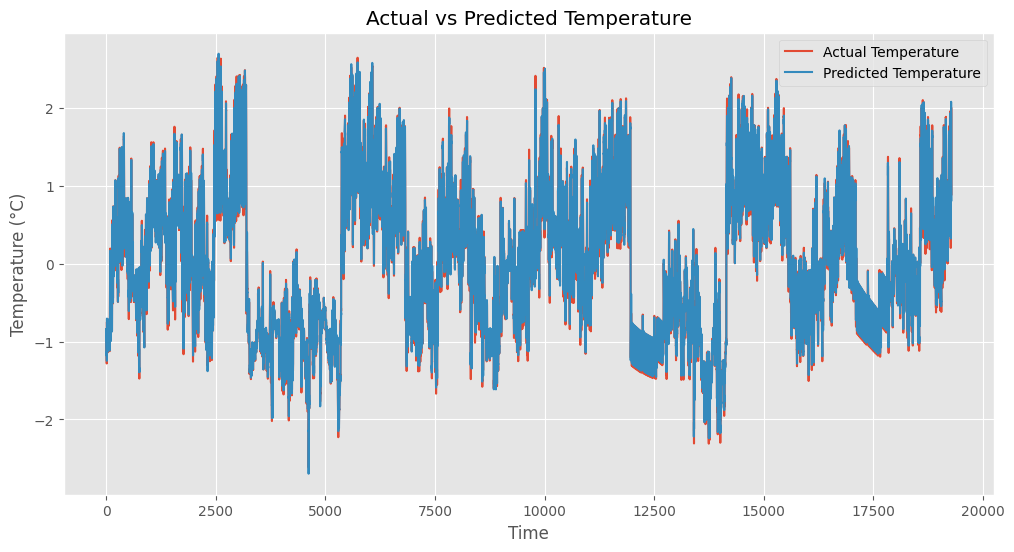

In [95]:
plt.figure(figsize=(12,6))

plt.plot(
    actual,
    label="Actual Temperature"
)

plt.plot(
    prediction,
    label="Predicted Temperature"
)

plt.title("Actual vs Predicted Temperature")

plt.xlabel("Time")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.show()

# Deep Learning Summary

A Long Short-Term Memory (LSTM) neural network was successfully developed for weather prediction using sequential meteorological observations. The model demonstrated the ability to capture temporal dependencies within the weather data and generate future temperature predictions.

Compared with traditional machine learning algorithms, LSTM networks offer enhanced capability for modelling sequential atmospheric processes, making them particularly suitable for time-series weather forecasting applications.

The developed deep learning model complements the machine learning models developed earlier and forms an advanced predictive component of the Intelligent Multi-Modal Weather Intelligence and Climate Decision Support Platform.